# Классификация исхода при первичном билиарном холангите

Данные: [Mayo Clinic PBC](https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/survival/pbc.csv)
(Fleming & Harrington, 1991) — 418 пациентов рандомизированного испытания D-пеницилламина.

Таргет `Status`: **C** — наблюдение прекращено, **CL** — пересадка печени, **D** — смерть.
Метрика — **multi-class log loss** (меньше лучше), рядом смотрим accuracy и balanced accuracy.

Логика вынесена в `src/`, ноутбук — разбор по шагам.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))

from data import load
from train import (
    CLASSES, N_SPLITS, PARAMS, baseline_probabilities, build_features,
    cross_validate, report_metrics,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

## Данные

In [2]:
df = load()
print(df.shape)
df.head()

(418, 20)


,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,1,400,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0,D
1,2,4500,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0,C
2,3,1012,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0,D
3,4,1925,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0,D
4,5,1504,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0,CL


## Разведочный анализ

Два обстоятельства определяют всё дальнейшее: сильный дисбаланс классов и настоящие пропуски.

In [3]:
counts = df["Status"].value_counts()
print(counts)
print()
print((counts / len(df) * 100).round(1).astype(str) + " %")

Status
C     232
D     161
CL     25
Name: count, dtype: int64

Status
C     55.5 %
D     38.5 %
CL     6.0 %
Name: count, dtype: str


In [4]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pd.DataFrame({"пропусков": missing, "доля": (missing / len(df) * 100).round(1)})

,пропусков,доля
Tryglicerides,136,32.5
Cholesterol,134,32.1
Copper,108,25.8
Drug,106,25.4
Spiders,106,25.4
Hepatomegaly,106,25.4
Ascites,106,25.4
Alk_Phos,106,25.4
SGOT,106,25.4
Platelets,11,2.6


Пропуски сосредоточены в лабораторных показателях, и это не случайность: 106 из 418 пациентов
не входили в рандомизированное испытание, поэтому у них нет ни назначенного препарата, ни части
анализов. Сам факт пропуска несёт информацию, так что заполнять его средним не нужно —
XGBoost умеет работать с NaN и выбирает направление ветвления для них сам.

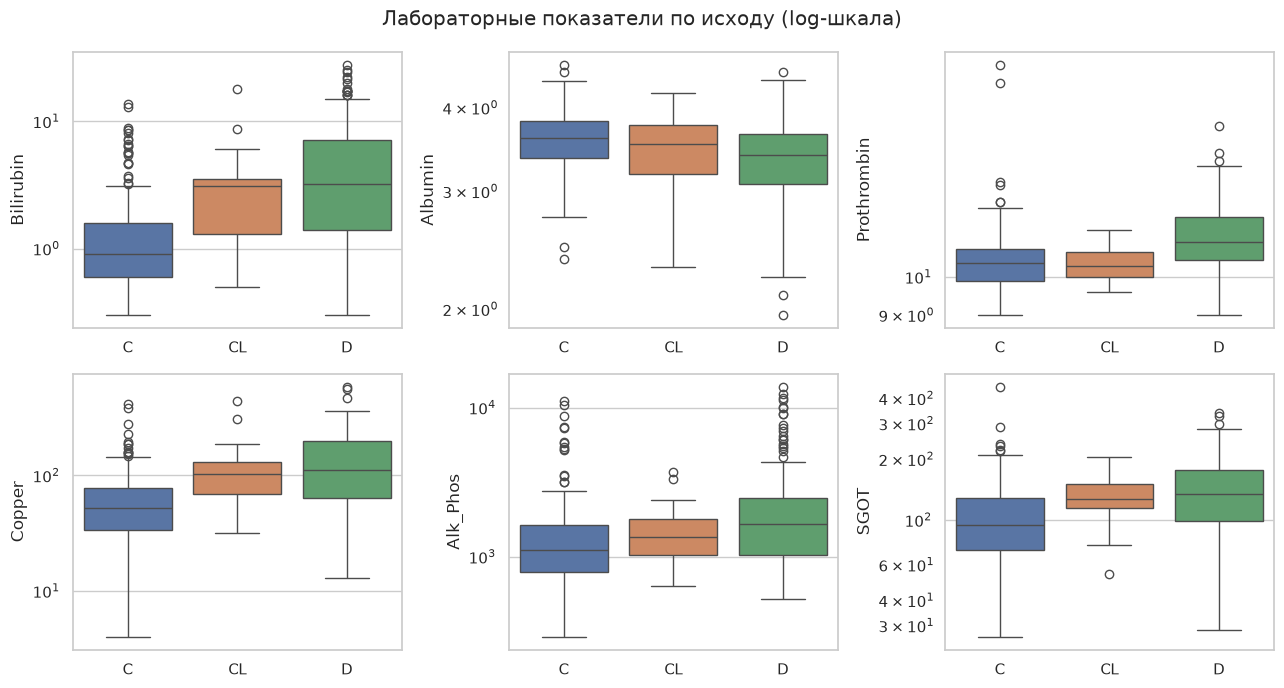

In [5]:
labs = ["Bilirubin", "Albumin", "Prothrombin", "Copper", "Alk_Phos", "SGOT"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.ravel(), labs):
    sns.boxplot(data=df, x="Status", y=col, order=CLASSES, hue="Status",
                hue_order=CLASSES, legend=False, ax=ax)
    ax.set_yscale("log")
    ax.set_xlabel("")
fig.suptitle("Лабораторные показатели по исходу (log-шкала)")
fig.tight_layout()
plt.show()

Картина клинически ожидаемая: у умерших пациентов выше билирубин, протромбиновое время и медь,
ниже альбумин. То есть сигнал в данных есть, и он совпадает с известными прогностическими
факторами модели Mayo.

## Подготовка признаков

Все категории здесь либо бинарные, либо упорядоченные (`Edema`: нет < слабый < есть), поэтому
целочисленные коды не навязывают ложного порядка. Словари кодировки заданы явно и зафиксированы
в `src/train.py` — это важно, потому что `pd.factorize`, применённый к train и test по
отдельности, выдал бы разные коды для одних и тех же категорий.

In [6]:
X, y = build_features(df)
print(f"{X.shape[0]} пациентов, {X.shape[1]} признаков")
print(f"доля пропусков: {X.isna().to_numpy().mean():.1%}")
X.head()

418 пациентов, 18 признаков
доля пропусков: 13.7%


,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400.0,0.0,21464.0,0.0,1.0,1.0,1.0,2.0,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,4500.0,0.0,20617.0,0.0,0.0,1.0,1.0,0.0,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,1012.0,0.0,25594.0,1.0,0.0,0.0,0.0,1.0,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,1925.0,0.0,19994.0,0.0,0.0,1.0,1.0,1.0,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,1504.0,1.0,13918.0,0.0,0.0,1.0,1.0,0.0,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


## Валидация

Датасет маленький — 418 строк, из них всего 25 в классе `CL`. Одиночное разбиение 80/20 дало бы
5 примеров редкого класса в валидации, и метрика скакала бы от сида. Поэтому берём
стратифицированную 5-fold CV и собираем out-of-fold предсказания по всем пациентам.

In [7]:
oof = cross_validate(X, y)

  фолд 1: log loss = 0.6692


  фолд 2: log loss = 0.6197


  фолд 3: log loss = 0.5571


  фолд 4: log loss = 0.5515


  фолд 5: log loss = 0.7446


In [8]:
_ = report_metrics("XGBoost (out-of-fold)", y, oof)
_ = report_metrics("Baseline (априорные вероятности)", y, baseline_probabilities(y))


XGBoost (out-of-fold)
  log loss           0.6283
  accuracy           0.7392
  balanced accuracy  0.5394
  macro F1           0.5447

Baseline (априорные вероятности)
  log loss           0.8627
  accuracy           0.5550
  balanced accuracy  0.3333
  macro F1           0.2379


Модель уверенно лучше тривиальной: log loss 0.63 против 0.86, accuracy 0.74 против 0.56.
Проверка против baseline здесь обязательна — на несбалансированных данных accuracy 0.74
сама по себе ничего не значит, пока не видно, что даёт постоянное предсказание
мажоритарного класса.

              precision    recall  f1-score   support

           C       0.76      0.84      0.80       232
          CL       0.29      0.08      0.12        25
           D       0.72      0.70      0.71       161

    accuracy                           0.74       418
   macro avg       0.59      0.54      0.54       418
weighted avg       0.72      0.74      0.72       418



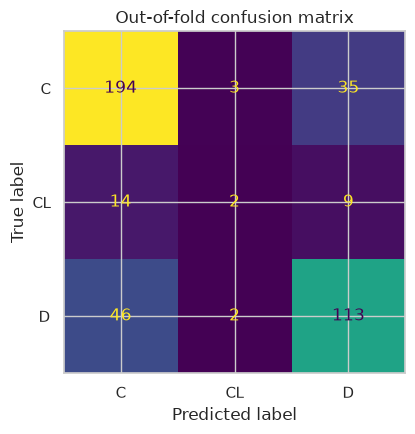

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

print(classification_report(y, oof.argmax(axis=1), target_names=CLASSES, zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y, oof.argmax(axis=1), display_labels=CLASSES, ax=ax, colorbar=False,
)
ax.set_title("Out-of-fold confusion matrix")
fig.tight_layout()
plt.show()

Класс `CL` практически не распознаётся: recall 0.08 при 25 примерах. Это ограничение данных,
а не гиперпараметров — пересадка печени по лабораторным показателям почти не отличается от
продолжения наблюдения. Скрывать это смысла нет, поэтому в отчёте рядом с accuracy стоит
balanced accuracy, которая этот провал показывает.

## Важность признаков

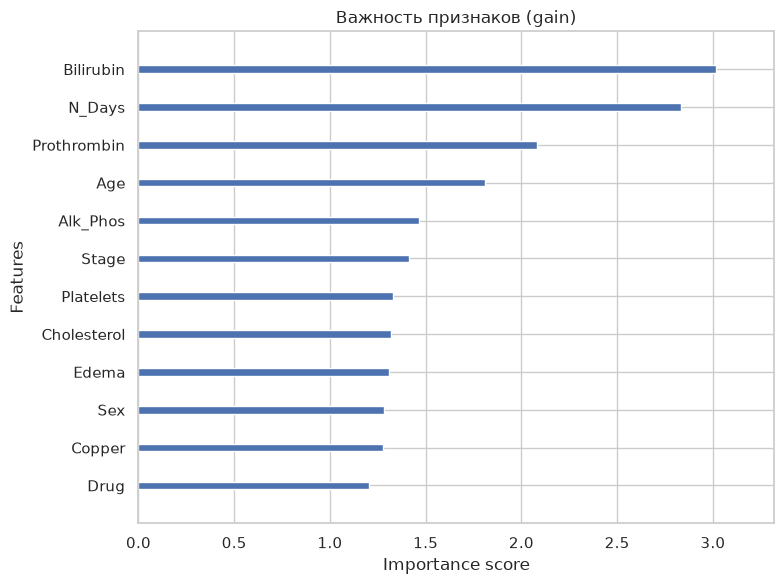

In [10]:
from xgboost import XGBClassifier, plot_importance

model = XGBClassifier(**PARAMS).fit(X, y)

fig, ax = plt.subplots(figsize=(8, 6))
plot_importance(model, ax=ax, max_num_features=12, importance_type="gain",
                show_values=False, title="Важность признаков (gain)")
fig.tight_layout()
plt.show()

## Выводы

1. Билирубин, длительность наблюдения, протромбиновое время и возраст — самые сильные признаки,
   что согласуется с прогностической моделью Mayo для ПБХ.
2. XGBoost на стратифицированной 5-fold CV даёт log loss **0.63** против **0.86** у baseline.
3. Редкий класс `CL` остаётся нераспознанным; на 25 примерах это не лечится подбором
   гиперпараметров.